# Reproducing the paper figures

Regenerates every code-generated figure of *From Third-Party to First-Party:
Measuring and Protecting Against Modern Web Tracking Mechanisms* (ACSAC 2026)
from files tracked in this repository. No BigQuery access and no Zenodo
download is needed.

The plotting code is ported cell-for-cell from the analysis notebooks and
scripts identified in [`docs/figures.md`](../../docs/figures.md); that document
also records the inputs, the blockers, and the checks behind each mapping.
Figures are not part of the byte-exact claim scripts.

| Figure | Source of the ported code | Input (tracked) |
|---|---|---|
| 1 | manual drawing, not code-generated | — |
| 2 | `Code/Analysis/JavaScript/overview.ipynb`, cell 15 | `02_Data/js_hashes/simhash_to_profile_export.csv` |
| 3 | `Code/Analysis/ecosystem/overview.ipynb`, cell 5 | `Code/Analysis/ecosystem/cluster_sizes_{raw_,}27112025.csv` |
| 4 | `Code/Analysis/ecosystem/network_graph/network_graph_paper.ipynb`, cells 0–3 | `Code/Analysis/ecosystem/network_graph/top5_cluster_to_cookies.csv` |
| 5, 6 | `06_RuleSet_Generation/RuleSet_Mining/generate_features&plots.py` | `06_RuleSet_Generation/RuleSet_Mining/data_02022026/positive.csv` |

**Runtime:** about 1 minute for "Run all" (measured: 56 s wall-clock, 50 s
kernel time on a laptop; Figure 4's force-directed layout takes 45 s of it).

**Requirements:** `pip install -r Code/Figures/requirements-figures.txt`
(matplotlib, pandas, networkx, upsetplot, jupyter — pinned separately from the
claim scripts' `requirements.txt`, which does not include `upsetplot` or
Jupyter). Then run the notebook from anywhere inside the repository:

```bash
jupyter nbconvert --to notebook --execute --inplace Code/Figures/reproduce_figures.ipynb
```

**Output:** PDFs are written to `Code/Figures/output/` (git-ignored, created on
the fly). The committed outputs below were produced with the pinned versions and
serve as the reference renderings.

Run the setup cell first; after that every figure cell is self-contained and can
be executed on its own.

## Setup

In [1]:
# Shared imports and helpers. Run this cell first; every figure cell below
# loads its own data and only relies on what is defined here.
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Show only the exception type and message for errors raised in this notebook,
# so a missing input file yields a one-line hint instead of a traceback.
get_ipython().run_line_magic("xmode", "Minimal")


def find_repo_root() -> Path:
    """Locate the repository root from the current working directory.

    Jupyter kernels have no __file__, so walk up from Path.cwd() until the
    directory containing metadata.toml and 02_Data/ is found.
    """
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "metadata.toml").is_file() and (candidate / "02_Data").is_dir():
            return candidate
    raise RuntimeError(
        "Repository root not found. Start Jupyter from inside the cloned "
        "repository (any subdirectory works), e.g. "
        "`jupyter notebook Code/Figures/reproduce_figures.ipynb` from the root."
    )


REPO_ROOT = find_repo_root()
OUTPUT_DIR = REPO_ROOT / "Code" / "Figures" / "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)


class MissingInput(Exception):
    """Raised when a tracked input file is not where the repository expects it."""


def input_path(*parts: str) -> Path:
    """Resolve a repository-relative input path and check that it exists."""
    path = REPO_ROOT.joinpath(*parts)
    if not path.is_file():
        raise MissingInput(
            f"Input file not found: {path.relative_to(REPO_ROOT)}\n"
            "This file is tracked in Git; re-check the clone (git status, git lfs "
            "is not used) or see docs/figures.md for the expected inputs."
        )
    return path


print(f"Repository root: {REPO_ROOT}")
print(f"Output directory: {OUTPUT_DIR.relative_to(REPO_ROOT)}")

Exception reporting mode: Minimal
Repository root: D:\From-Third-Party-to-First-Party-Measuring-and-Protecting-Against-Modern-Web-Tracking-Mechanisms
Output directory: Code\Figures\output


## Figure 1 — Concept diagram

Concept diagram, created manually
([`Code/Analysis/Figures/SST_CST.drawio`](../Analysis/Figures/SST_CST.drawio),
diagrams.net). Not code-generated.

## Figure 2 — Exclusive intersections of observed scripts across the four profiles

UpSet plot over the SimHashes of the tracking scripts observed by each crawl
profile. Ported from `Code/Analysis/JavaScript/overview.ipynb`, cell 15
(`upset_plot_tracking_scripts.pdf`).

The profile label is derived from the `browser_id` column of the export, not
from a file name. `docs/figures.md` documents that the untracked
`all_hashes - <profile>.csv` files behind the all-scripts variant carry EU/US
labels swapped relative to the `browser_id`-labelled data, so file names are not
a trustworthy source of the profile here.

Distinct tracking-script SimHashes per profile: {'EU1': 21119, 'EU2': 19092, 'US1': 9862, 'US2': 11437}


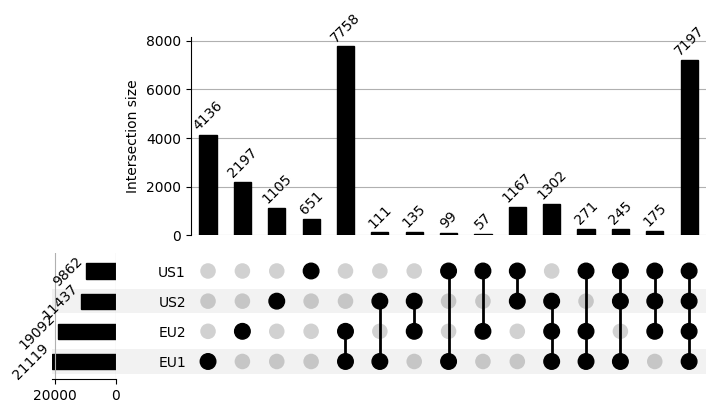

In [2]:
import warnings

from upsetplot import UpSet, from_contents

# upsetplot 0.9.0 triggers pandas FutureWarnings about in-place fillna, and
# tight_layout() warns that UpSet's GridSpec axes are not compatible with it
# (kept from the source notebook; the rendering matches). Neither affects the plot.
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")
warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible with tight_layout")

# Profile label from browser_id (the crawl profile that observed the script).
BROWSER_ID_TO_PROFILE = {
    "openwpm_native_eu_1_omaticall": "EU1",
    "openwpm_native_eu_2_omaticall": "EU2",
    "openwpm_native_us_1_omaticall": "US1",
    "openwpm_native_us_2_omaticall": "US2",
}

df = pd.read_csv(input_path("02_Data", "js_hashes", "simhash_to_profile_export.csv"))
df["profile"] = df["browser_id"].map(BROWSER_ID_TO_PROFILE)
unmapped = df["profile"].isna().sum()
assert unmapped == 0, f"{unmapped} rows have an unknown browser_id"

sets = {
    profile: set(df.loc[df["profile"] == profile, "simhash_hex"])
    for profile in ["EU1", "EU2", "US1", "US2"]
}
print("Distinct tracking-script SimHashes per profile:",
      {p: len(s) for p, s in sets.items()})

data = from_contents(sets)

fig = plt.figure(figsize=(8, 6))
up = UpSet(data, subset_size="count", show_counts=True)
up.plot(fig=fig)

# Rotate the bar-count labels so they do not overlap.
for ax in fig.axes:
    for txt in ax.texts:
        txt.set_rotation(45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure2_upset_tracking_scripts.pdf", dpi=300)
plt.show()

In [3]:
# All-scripts variant (cell 11 of the source notebook, `upset_plot.pdf`).
# Requires the full Zenodo dataset: the four per-profile fingerprint exports
# 02_Data/js_hashes/{EU1,EU2,US1,US2}_hashes.csv (113-166 MB each, git-ignored).
# The original cell globbed `all_hashes - *.csv` and took the profile from the
# file name; those files are not part of the repository. The Zenodo files carry
# the same SimHash sets under the browser_id-consistent labels (see
# docs/figures.md, "Figure 2"), so the block below reads them by profile name.
#
# from upsetplot import UpSet, from_contents
#
# sets = {}
# for profile in ["EU1", "EU2", "US1", "US2"]:
#     path = input_path("02_Data", "js_hashes", f"{profile}_hashes.csv")
#     sets[profile] = set(pd.read_csv(path, usecols=["simhash_hex"])["simhash_hex"])
# print("Distinct SimHashes per profile:", {p: len(s) for p, s in sets.items()})
#
# data = from_contents(sets)
# fig = plt.figure(figsize=(8, 6))
# up = UpSet(data, subset_size="count", show_counts=True)
# up.plot(fig=fig)
# for ax in fig.axes:
#     for txt in ax.texts:
#         txt.set_rotation(45)
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "figure2_upset_all_scripts.pdf", dpi=300)
# plt.show()

## Figure 3 — Distribution of cluster sizes

Empirical CDF of the cluster size measured two ways: by the number of unique
scripts (SimHashes) in the cluster and by the number of URLs the cluster
accounts for. Ported from `Code/Analysis/ecosystem/overview.ipynb`, cell 5
(`cluster_sizes_cdf.pdf`). Both inputs are frozen exports of the `cluster_k8`
join with 24,914 rows each.

24,914 clusters by unique scripts, 24,914 clusters by URLs


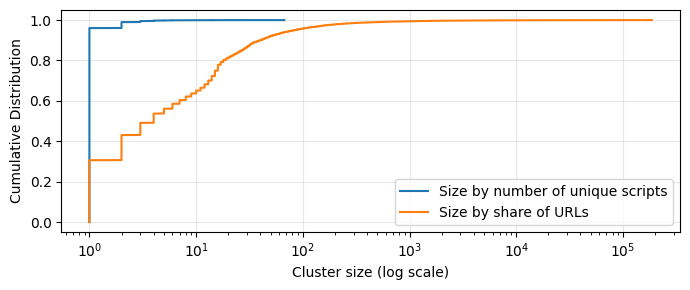

In [4]:
raw_df = pd.read_csv(input_path("Code", "Analysis", "ecosystem", "cluster_sizes_raw_27112025.csv"))
raw_cluster_size = raw_df["cluster_size"].to_numpy()

total_df = pd.read_csv(input_path("Code", "Analysis", "ecosystem", "cluster_sizes_27112025.csv"))
cluster_size = total_df["number_of_site_data"].to_numpy()
print(f"{len(raw_cluster_size):,} clusters by unique scripts, {len(cluster_size):,} clusters by URLs")

# Sort values for empirical CDF
raw_sorted = np.sort(raw_cluster_size)
total_sorted = np.sort(cluster_size)

# Empirical CDF computation
raw_cdf = np.arange(1, len(raw_sorted) + 1) / len(raw_sorted)
total_cdf = np.arange(1, len(total_sorted) + 1) / len(total_sorted)

# Plot CDF with two lines
plt.figure(figsize=(7, 3))

plt.plot(raw_sorted, raw_cdf, label="Size by number of unique scripts", linewidth=1.5)
plt.plot(total_sorted, total_cdf, label="Size by share of URLs", linewidth=1.5)

plt.xlabel("Cluster size (log scale)")
plt.xscale("log")
plt.ylabel("Cumulative Distribution")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure3_cluster_sizes_cdf.pdf", dpi=600)
plt.show()

## Figure 4 — Network graph of the top-5 clusters by site data

Bipartite graph between the five clusters with the most site data (grey nodes)
and the cookies set by scripts in those clusters (red nodes, sized by degree).
Ported from `Code/Analysis/ecosystem/network_graph/network_graph_paper.ipynb`,
cells 0–3 (`Ecosystem_Top_5_Cluster.pdf`). The input is a frozen export of
`Code/Queries/top_cluster.sql`.

The spring layout is seeded (`seed=3113794652`, as in the source notebook), so
the drawing is deterministic for a given NetworkX version (pinned in
`requirements-figures.txt`). **Runtime: about 45 seconds** — 300 layout
iterations over roughly 1,000 nodes.

5 clusters, 978 cookies, 2744 edges


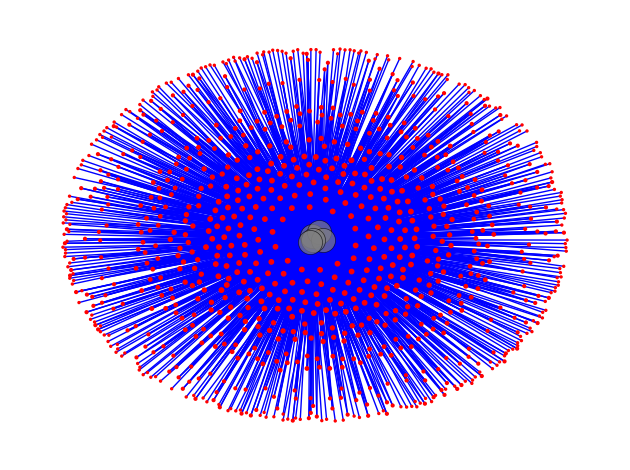

In [5]:
import networkx as nx

LAYOUT_SEED = 3113794652  # same seed as the source notebook; fixes the drawing

df_cookies_top5_cluster = pd.read_csv(
    input_path("Code", "Analysis", "ecosystem", "network_graph", "top5_cluster_to_cookies.csv")
)

# One edge per (cookie, cluster) pair.
list_of_cookies = list(set(df_cookies_top5_cluster["cookie"].tolist()))
df_grouped = df_cookies_top5_cluster.groupby("cookie")

edges = list()
for cookie in list_of_cookies:
    _df = df_grouped.get_group(cookie)
    for cluster_id in list(set(_df["id"].tolist())):
        edges.append((cookie, cluster_id))

cluster_set = list(set(df_cookies_top5_cluster["id"]))
print(f"{len(cluster_set)} clusters, {len(list_of_cookies)} cookies, {len(edges)} edges")

G = nx.Graph()
G.add_edges_from(edges)

pos = nx.spring_layout(
    G,
    k=2,
    scale=150,
    iterations=300,
    seed=LAYOUT_SEED,
)

cookie_degrees = {node: G.degree(node) for node in list_of_cookies}
node_sizes_cookies = [cookie_degrees[node] * 2 for node in list_of_cookies]

nx.draw_networkx_nodes(G, pos=pos, nodelist=list_of_cookies, node_color="red", node_size=node_sizes_cookies)
nx.draw_networkx_nodes(G, pos=pos, nodelist=cluster_set, node_color="grey", alpha=0.7,
                       edgecolors="black", linewidths=0.5)
nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color="blue")

plt.tight_layout()
plt.axis("off")
plt.savefig(OUTPUT_DIR / "figure4_top5_cluster_graph.pdf", format="pdf", orientation="landscape")
plt.show()

## Figures 5 and 6 — Query-key rank-frequency distribution and cumulative coverage

Figure 5 is the rank-frequency distribution of the query-parameter keys in the
positive (tracking) URL set on a logarithmic y-axis; Figure 6 is the cumulative
share of key occurrences covered by the top-*N* keys, with the N95 and N99
cutoffs marked.

The key extraction is imported from
`06_RuleSet_Generation/RuleSet_Mining/generate_features&plots.py`; the two
plotting functions are ported from the same file with `plt.close()` replaced by
`plt.show()` so the figures render inline. The input is the full positive set
`data_02022026/positive.csv`. Its N99 cutoff of 161 keys is the count baked into
the downstream mining artefacts (`fpg_outputs_max_depth__161/`), which
identifies it as the paper's input; the cell asserts this.

Finished scanning 86,831 rows.
Found 940 unique query keys.
Figure 5


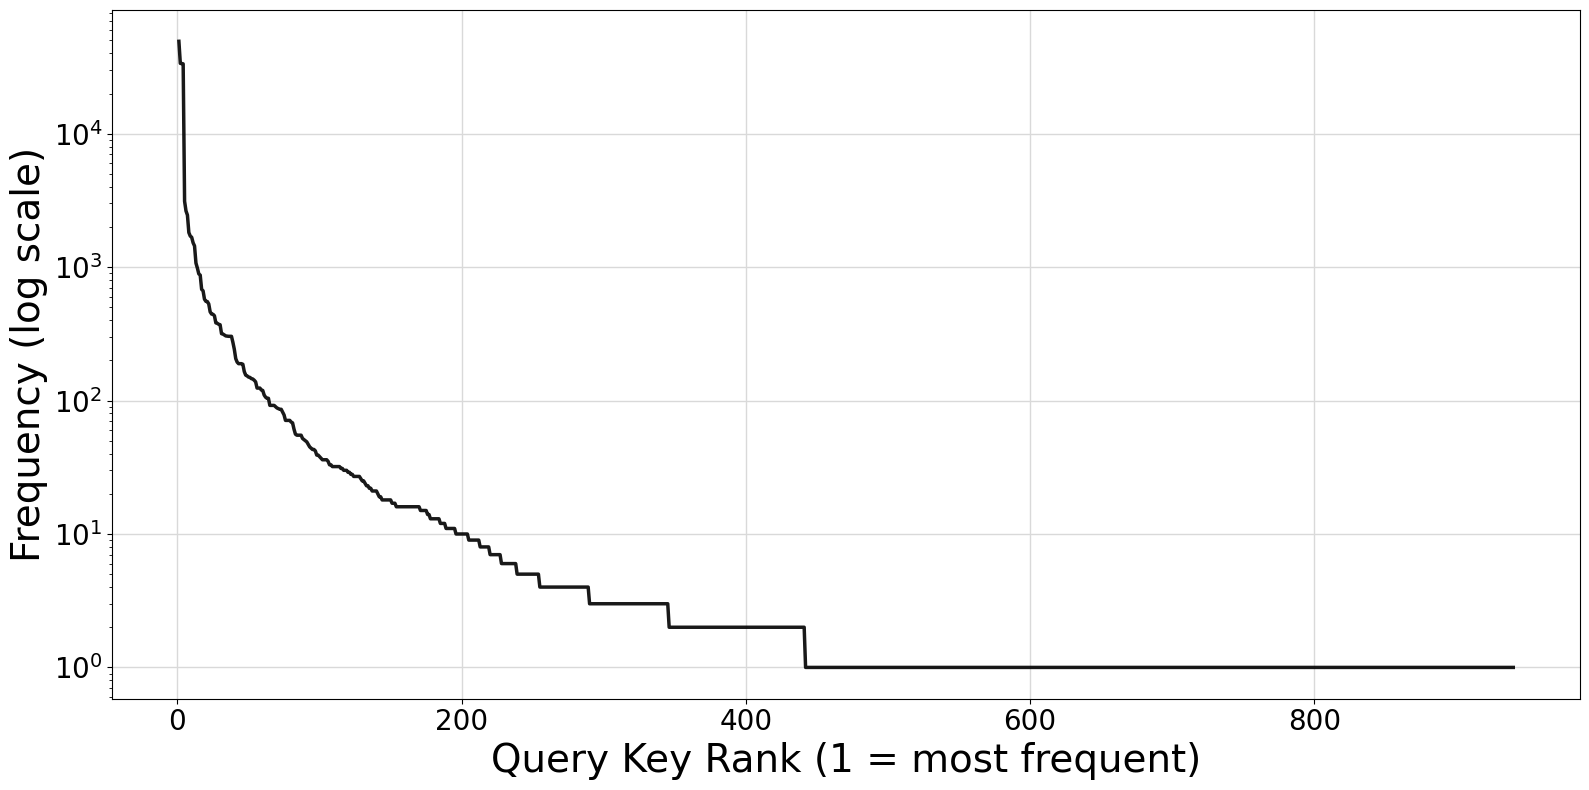

Figure 6


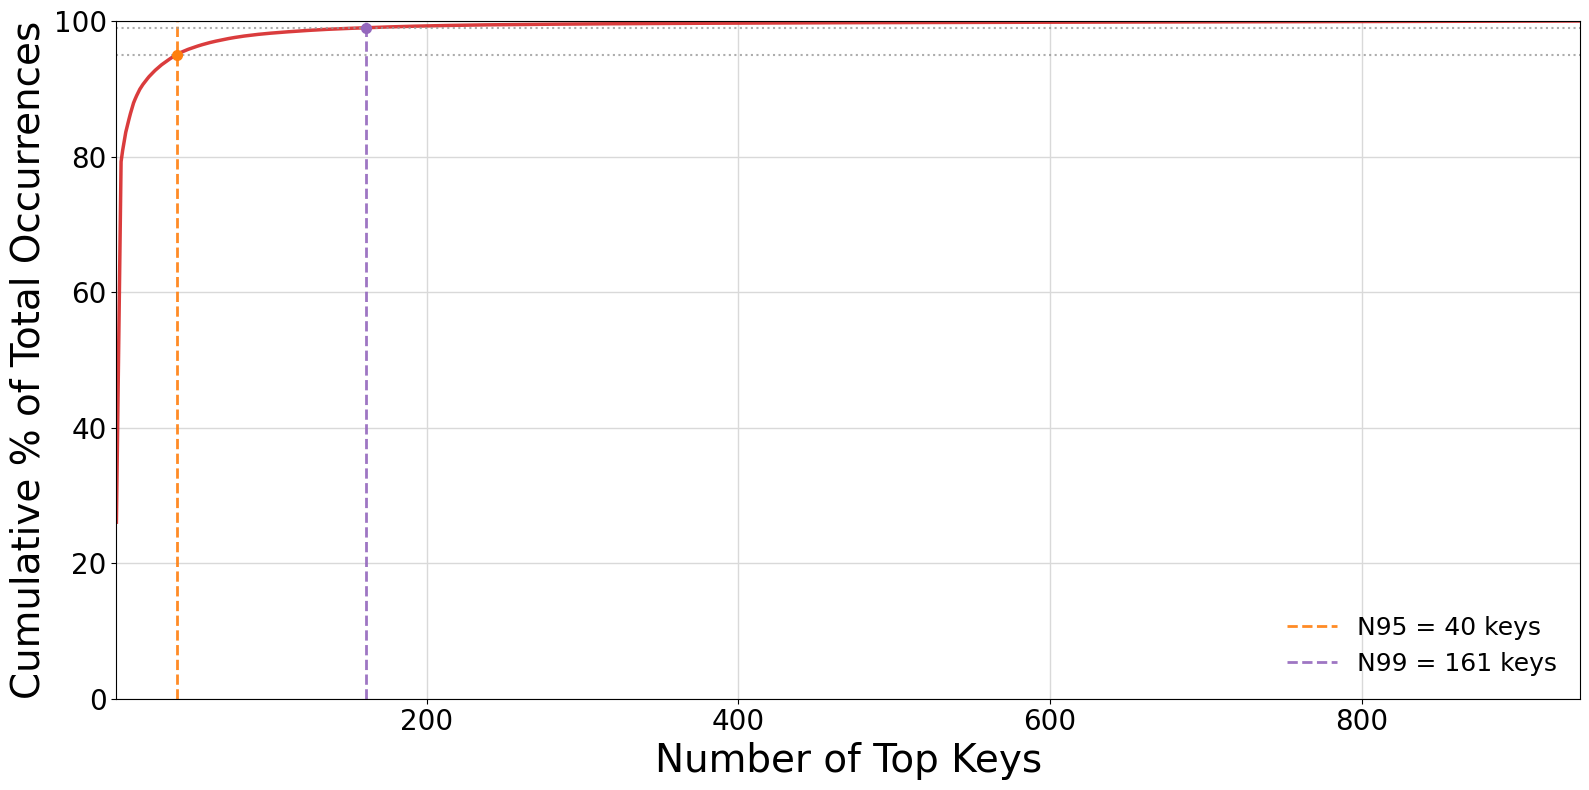

Pareto cutoffs: N95=40 keys, N99=161 keys


In [6]:
import importlib.util

import matplotlib
from matplotlib import rcParams

# The script name contains '&', so it cannot be imported with a plain import
# statement; load it by path instead. It calls matplotlib.use("Agg") on import,
# which would disable inline rendering, so the notebook backend is restored.
_script = REPO_ROOT / "06_RuleSet_Generation" / "RuleSet_Mining" / "generate_features&plots.py"
if not _script.is_file():
    raise MissingInput(f"Script not found: {_script.relative_to(REPO_ROOT)}")
_backend = matplotlib.get_backend()
_spec = importlib.util.spec_from_file_location("generate_features_plots", _script)
gfp = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(gfp)
matplotlib.use(_backend)

positive_csv = input_path("06_RuleSet_Generation", "RuleSet_Mining", "data_02022026", "positive.csv")
key_counter = gfp.build_key_counter(input_csv=str(positive_csv), url_column="url", chunksize=10_000)
counts_desc = gfp._counts_desc(key_counter)


def plot_key_distribution(counts_desc, output_path):
    """Rank-frequency plot (log-y). Ported from gfp.plot_key_distribution."""
    x = np.arange(1, len(counts_desc) + 1)
    y = np.array(counts_desc, dtype=float)

    rcParams["figure.figsize"] = 16, 8
    plt.plot(x, y, color="black", linewidth=2.5, alpha=0.9)
    plt.yscale("log")
    plt.grid(True, color="0.85", linewidth=1, alpha=1.0)
    plt.xlabel("Query Key Rank (1 = most frequent)", fontsize=28)
    plt.ylabel("Frequency (log scale)", fontsize=28)
    # No title (paper-friendly); rely on caption in LaTeX.
    plt.tick_params(axis="both", which="major", labelsize=20)
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight", dpi=600, format="pdf")
    plt.show()


def plot_cumulative_pareto(counts_desc, output_path):
    """Cumulative distribution with N95/N99 cutoffs. Ported from gfp.plot_cumulative_pareto."""
    counts = np.array(counts_desc, dtype=float)
    cumsum = np.cumsum(counts)
    cumsum_pct = (cumsum / cumsum[-1]) * 100.0
    x = np.arange(1, len(cumsum_pct) + 1)

    n95 = int(np.argmax(cumsum_pct >= 95.0) + 1)
    n99 = int(np.argmax(cumsum_pct >= 99.0) + 1)

    rcParams["figure.figsize"] = 16, 8
    plt.plot(x, cumsum_pct, color="tab:red", linewidth=2.5, alpha=0.9)
    plt.grid(True, color="0.85", linewidth=1, alpha=1.0)
    plt.ylim(0, 100)
    plt.xlim(1, len(cumsum_pct))
    plt.xlabel("Number of Top Keys", fontsize=28)
    plt.ylabel("Cumulative % of Total Occurrences", fontsize=28)
    plt.tick_params(axis="both", which="major", labelsize=20)

    # Cutoff lines + markers.
    plt.axvline(x=n95, color="tab:orange", linestyle="--", alpha=0.9, linewidth=2, label=f"N95 = {n95} keys")
    plt.axvline(x=n99, color="tab:purple", linestyle="--", alpha=0.9, linewidth=2, label=f"N99 = {n99} keys")
    plt.axhline(y=95, color="0.6", linestyle=":", alpha=0.8)
    plt.axhline(y=99, color="0.6", linestyle=":", alpha=0.8)
    plt.plot([n95], [95], "o", color="tab:orange", markersize=7)
    plt.plot([n99], [99], "o", color="tab:purple", markersize=7)

    plt.legend(loc="lower right", fontsize=18, frameon=False)
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight", dpi=600, format="pdf")
    plt.show()

    return n95, n99


print("Figure 5")
plot_key_distribution(counts_desc, OUTPUT_DIR / "figure5_query_key_distribution.pdf")

print("Figure 6")
n95, n99 = plot_cumulative_pareto(counts_desc, OUTPUT_DIR / "figure6_query_key_cumulative_pareto.pdf")
print(f"Pareto cutoffs: N95={n95} keys, N99={n99} keys")

# 161 keys is the N99 count the rest of the mining pipeline was built on
# (fpg_outputs_max_depth__161/, *_with_query_keys_positive_161.csv).
assert n99 == 161, f"expected N99 = 161 keys for positive.csv, got {n99}"

rcParams["figure.figsize"] = matplotlib.rcParamsDefault["figure.figsize"]

## Generated files

In [7]:
pdfs = sorted(OUTPUT_DIR.glob("*.pdf"))
if not pdfs:
    print(f"No PDFs in {OUTPUT_DIR.relative_to(REPO_ROOT)} - run the figure cells above first.")
for pdf in pdfs:
    print(f"{pdf.relative_to(REPO_ROOT).as_posix():<60} {pdf.stat().st_size / 1024:8.1f} KB")

Code/Figures/output/figure2_upset_tracking_scripts.pdf           18.2 KB
Code/Figures/output/figure3_cluster_sizes_cdf.pdf                17.8 KB
Code/Figures/output/figure4_top5_cluster_graph.pdf              176.0 KB
Code/Figures/output/figure5_query_key_distribution.pdf           14.8 KB
Code/Figures/output/figure6_query_key_cumulative_pareto.pdf      14.6 KB
